In [2]:
# Este comando descarga el repositorio entero a una carpeta llamada 'TFMDS' en Colab.
!git clone https://github.com/jmorala/TFMDS.git

Cloning into 'TFMDS'...
remote: Enumerating objects: 530, done.
remote: Counting objects: 100% (91/91), done.
remote: Compressing objects: 100% (53/53), done.
remote: Total 530 (delta 44), reused 66 (delta 38), pack-reused 439 (from 2)
Receiving objects: 100% (530/530), 201.45 MiB | 22.60 MiB/s, done.
Resolving deltas: 100% (249/249), done.
Updating files: 100% (99/99), done.


# Inicializar directorios
Clonar repositorio github
Posicionarse en el directorio raíz

In [3]:
import os
import sys

# ============================================================================
# CONFIGURACIÓN DE DIRECTORIOS
# ============================================================================

# Detectar si estamos en Google Colab
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Configurar el directorio de trabajo según el entorno
if IN_COLAB:
    project_dir = '/content/TFMDS'
    os.chdir(project_dir)
else:
    # Detectar si estamos en Codespaces o VS Code local
    if os.path.exists('/workspaces/TFMDS'):
        # Entorno Codespaces
        os.chdir('/workspaces/TFMDS')
    else:
        # En VS Code local, nos movemos al directorio raíz del proyecto
        project_dir = r'C:\Users\jmora\Documents\TFMDS'
        os.chdir(project_dir)

# Agregar el directorio del proyecto al path de Python
if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())

print("Directorio de trabajo:", os.getcwd())
print("Python path incluye proyecto:", os.getcwd() in sys.path)

Directorio de trabajo: /content/TFMDS
Python path incluye proyecto: True


In [5]:
!pip install neuralforecast

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.2/263.2 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 287.4/287.4 kB 29.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 849.5/849.5 kB 56.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.3/72.3 MB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 32.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.2/102.2 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 67.8 MB/s eta 0:00:00
  Attempting uninstall: click
    Found existing installation: click 8.3.1
    Uninstalling click-8.3.1:
      Successfully uninstalled click-8.3.1


In [6]:
# ============================================================================
# IMPORTACIONES BASE Y VERSIÓN
# ============================================================================
import os, sys
import pandas as pd
import numpy as np
import time

import torch
import pytorch_lightning as pl
from neuralforecast import NeuralForecast, __version__ as nf_version
from neuralforecast.models import VanillaTransformer
from neuralforecast.losses.pytorch import MAE

# Importar utilidades desde la carpeta 'lib' evitando el paquete
lib_dir = os.path.join(os.getcwd(), 'lib')
if lib_dir not in sys.path:
    sys.path.insert(0, lib_dir)

from lib.dl_utils import (
    preparar_datos_neuralforecast,
    seleccionar_features_exogenas,
    reconstruir_predicciones,
    preparar_variables_estaticas,
)
from lib.metricas import calcular_metricas, comparar_metricas, resumen_metricas, agregar_estadisticas_error, resumen_final_modelos
from lib.graficos_dl import (
    grafico_prediccion_diaria_agregada,
    grafico_prediccion_por_cluster,
    grafico_productos_por_cluster,
    dashboard_metricas_dl,
    dashboard_prediccion_dl
)

print(f"torch: {torch.__version__}")
print(f"pytorch_lightning: {pl.__version__}")
print(f"neuralforecast: {nf_version}")

# ============================================================================
# DETECCIÓN Y CONFIGURACIÓN DE GPU
# ============================================================================
print("\n" + "="*100)
print("🔍 DETECTANDO HARDWARE DISPONIBLE")
print("="*100)

if torch.cuda.is_available():
    print(f"\n✅ GPU disponible: {torch.cuda.get_device_name(0)}")
    print(f"   Memoria GPU total: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    print(f"   Memoria GPU libre: {(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated(0)) / 1e9:.2f} GB")
    ACCELERATOR = 'gpu'
    DEVICES = 1
    print(f"\n🚀 Configuración: Entrenamiento con GPU habilitado")
else:
    print("\n⚠️ GPU no disponible, usando CPU")
    ACCELERATOR = 'cpu'
    DEVICES = 1
    print(f"\n💻 Configuración: Entrenamiento con CPU")

print(f"\nAccelerator: {ACCELERATOR}")
print(f"Devices: {DEVICES}")

torch: 2.9.0+cu126
pytorch_lightning: 2.6.0
neuralforecast: 3.1.2

🔍 DETECTANDO HARDWARE DISPONIBLE

✅ GPU disponible: Tesla T4
   Memoria GPU total: 15.83 GB
   Memoria GPU libre: 15.83 GB

🚀 Configuración: Entrenamiento con GPU habilitado

Accelerator: gpu
Devices: 1


# Lectura de datos preparados para Deep Learning

In [7]:
# ============================================================================
# LECTURA DE DATOS
# ============================================================================

print("\n" + "="*100)
print("📂 CARGANDO DATOS PARA DEEP LEARNING")
print("="*100)

# Datos normalizados para entrenamiento
df_train_raw = pd.read_csv('datos/df_train_dl.csv', sep=';', parse_dates=['idSecuencia'])
df_test_raw = pd.read_csv('datos/df_test_dl.csv', sep=';', parse_dates=['idSecuencia'])

print(f"\nDatos cargados:")
print(f"\nColumnas: {list(df_train_raw.columns)}")
print(f"   Train: {df_train_raw.shape}")
print(f"   Test:  {df_test_raw.shape}")


📂 CARGANDO DATOS PARA DEEP LEARNING

Datos cargados:

Columnas: ['idSecuencia', 'producto', 'udsVenta', 'bolPromocion', 'bolOpen', 'bolHoliday', 'lag_ventas_1', 'lag_ventas_2', 'lag_ventas_3', 'lag_ventas_4', 'lag_ventas_5', 'lag_ventas_6', 'lag_ventas_7', 'EWMA_corto', 'EWMA_largo', 'Tendencia_EWMA', 'dia_semana_sin', 'dia_semana_cos', 'mes_sin', 'mes_cos', 'semana_sin', 'semana_cos', 'Cluster_0', 'Cluster_1', 'Cluster_2', 'Cluster_3']
   Train: (625800, 26)
   Test:  (27714, 26)


# Preparación de datos para NeuralForecast

In [8]:
# ============================================================================
# PREPARACIÓN DE DATOS PARA NEURALFORECAST
# ============================================================================

print("\n" + "="*100)
print("🔧 PREPARANDO DATOS PARA NEURALFORECAST")
print("="*100)

# Convertir al formato NeuralForecast (unique_id, ds, y)
df_train_nf, df_test_nf = preparar_datos_neuralforecast(
    df_train_raw,
    df_test_raw,
    col_fecha='idSecuencia',
    col_producto='producto',
    col_target='udsVenta'
)

print(f"\n📋 Columnas: {list(df_train_nf.columns)}")
print(f"   Train: {df_train_nf.shape}")
print(f"   Test:  {df_test_nf.shape}")


🔧 PREPARANDO DATOS PARA NEURALFORECAST

📋 Columnas: ['ds', 'unique_id', 'y', 'bolPromocion', 'bolOpen', 'bolHoliday', 'lag_ventas_1', 'lag_ventas_2', 'lag_ventas_3', 'lag_ventas_4', 'lag_ventas_5', 'lag_ventas_6', 'lag_ventas_7', 'EWMA_corto', 'EWMA_largo', 'Tendencia_EWMA', 'dia_semana_sin', 'dia_semana_cos', 'mes_sin', 'mes_cos', 'semana_sin', 'semana_cos', 'Cluster_0', 'Cluster_1', 'Cluster_2', 'Cluster_3']
   Train: (625800, 26)
   Test:  (27714, 26)


# Configuración del modelo VanillaTransformer

## Arquitectura optimizada para GPU

El **Transformer "Vanilla"** es una arquitectura basada en **mecanismos de atención** desarrollada para impulsar avances en la inteligencia artificial, incluyendo la predicción de series temporales.

A diferencia de modelos secuenciales como las RNN, los **Transformers procesan la secuencia completa de datos a la vez**, evaluando todos los pasos de tiempo **simultáneamente**. Esta **perspectiva global** es crucial para capturar dependencias sin tener en cuenta la distancia temporal entre los elementos.

### Ventajas del entrenamiento con GPU:

1. **Paralelización masiva**: Los Transformers procesan múltiples secuencias simultáneamente
2. **Velocidad**: Entrenamiento 10-50x más rápido que en CPU
3. **Modelos más grandes**: Permite usar arquitecturas más profundas y complejas
4. **Batch sizes mayores**: Mejor convergencia y estabilidad en el entrenamiento

Los **componentes clave** de su arquitectura incluyen:

1.  **Mecanismo de Auto-atención** (*Self-attention*): Se utiliza para codificar la secuencia completa, calculando puntuaciones de relevancia entre todos los pares de valores de entrada y generando una combinación ponderada basada en ellas.
2.  **Atención Multi-cabeza** (*Multi-head attention*): Permite al modelo enfocarse en diferentes partes de la secuencia y en distintas características concurrentemente, lo cual es potente para manejar patrones complejos.
3.  **Codificación Posicional** (*Positional encoding*): Dado que el Transformer carece de la recursión inherente a las RNN, estas codificaciones se añaden a las entradas para asegurar que el modelo **reconozca el orden de los datos**.
4.  **Redes *Feedforward* Posicionales**: Aplicadas sobre la salida de la capa de atención para realizar transformaciones lineales.

## Preparar característias estáticas

In [9]:
# ============================================================================
# PREPARAR VARIABLES ESTÁTICAS
# ============================================================================

print("\n" + "="*100)
print("🔧 PREPARANDO VARIABLES ESTÁTICAS")
print("="*100)

# Definir columnas estáticas (que no varían en el tiempo)
stat_exog_list = ['Cluster_0', 'Cluster_1', 'Cluster_2', 'Cluster_3']

# Separar variables estáticas en DataFrame aparte
df_train_nf, df_test_nf, static_df = preparar_variables_estaticas(
    df_train_nf,
    df_test_nf,
    stat_exog_list
)

print(f"\n📋 Columnas df_train_nf: {list(df_train_nf.columns)}")


🔧 PREPARANDO VARIABLES ESTÁTICAS

✅ Variables estáticas extraídas:
   Columnas estáticas: ['Cluster_0', 'Cluster_1', 'Cluster_2', 'Cluster_3']
   Shape static_df: (894, 5)
   Productos únicos: 894

📊 Datasets temporales actualizados:
   Train: (625800, 22) (eliminadas 4 columnas)
   Test:  (27714, 22) (eliminadas 4 columnas)

📋 Columnas df_train_nf: ['ds', 'unique_id', 'y', 'bolPromocion', 'bolOpen', 'bolHoliday', 'lag_ventas_1', 'lag_ventas_2', 'lag_ventas_3', 'lag_ventas_4', 'lag_ventas_5', 'lag_ventas_6', 'lag_ventas_7', 'EWMA_corto', 'EWMA_largo', 'Tendencia_EWMA', 'dia_semana_sin', 'dia_semana_cos', 'mes_sin', 'mes_cos', 'semana_sin', 'semana_cos']


## Preparar características históricas

In [10]:
# =============================================================================
# LIMPIEZA DE FEATURES HISTÓRICAS (evitar NaN al inicio del test)
# =============================================================================

print("\n" + "="*100)
print("🧹 LIMPIANDO FEATURES HISTÓRICAS (hist_exog_list)")
print("="*100)

# Definir la lista de features históricas que usa el modelo
hist_exog_list = [
    'lag_ventas_1', 'lag_ventas_2', 'lag_ventas_3', 'lag_ventas_4',
    'lag_ventas_5', 'lag_ventas_6', 'lag_ventas_7',
    'EWMA_corto', 'EWMA_largo', 'Tendencia_EWMA'
]

# Comprobar existencia de columnas
def _check_missing(df, cols):
    return [c for c in cols if c not in df.columns]

missing_train = _check_missing(df_train_nf, hist_exog_list)
missing_test = _check_missing(df_test_nf, hist_exog_list)

if missing_train:
    print(f"⚠️ Faltan columnas en train: {missing_train}")
if missing_test:
    print(f"⚠️ Faltan columnas en test: {missing_test}")

cols_ok = [c for c in hist_exog_list if c in df_train_nf.columns and c in df_test_nf.columns]

if cols_ok:
    # Estadísticas antes
    na_train_before = int(df_train_nf[cols_ok].isna().sum().sum())
    na_test_before = int(df_test_nf[cols_ok].isna().sum().sum())

    # Forward fill por serie (unique_id) y rellenar remanentes al inicio con 0
    df_train_nf[cols_ok] = (
        df_train_nf.groupby('unique_id', observed=True)[cols_ok]
        .ffill()
        .fillna(0)
    )
    df_test_nf[cols_ok] = (
        df_test_nf.groupby('unique_id', observed=True)[cols_ok]
        .ffill()
        .fillna(0)
    )

    # Asegurar tipos numéricos (por si hubiera strings)
    for df_tmp in (df_train_nf, df_test_nf):
        for c in cols_ok:
            df_tmp[c] = pd.to_numeric(df_tmp[c], errors='coerce').fillna(0)

    # Estadísticas después
    na_train_after = int(df_train_nf[cols_ok].isna().sum().sum())
    na_test_after = int(df_test_nf[cols_ok].isna().sum().sum())

    print(f"✅ NaNs en train: {na_train_before} → {na_train_after}")
    print(f"✅ NaNs en test:  {na_test_before} → {na_test_after}")
else:
    print("⚠️ No hay columnas históricas válidas para limpiar.")

print("\n" + "="*100)
print(f"Features históricas {hist_exog_list}")


🧹 LIMPIANDO FEATURES HISTÓRICAS (hist_exog_list)
✅ NaNs en train: 3 → 0
✅ NaNs en test:  0 → 0

Features históricas ['lag_ventas_1', 'lag_ventas_2', 'lag_ventas_3', 'lag_ventas_4', 'lag_ventas_5', 'lag_ventas_6', 'lag_ventas_7', 'EWMA_corto', 'EWMA_largo', 'Tendencia_EWMA']


## Preparar características futuras

In [11]:
# FEATURES FUTURAS

futr_exog_list=[
        'bolOpen', 'bolHoliday', 'bolPromocion',
        'dia_semana_sin', 'dia_semana_cos',
        'mes_sin', 'mes_cos',
        'semana_sin', 'semana_cos'
    ]

print("\n" + "="*100)
print(f"Features futuras {futr_exog_list}")


Features futuras ['bolOpen', 'bolHoliday', 'bolPromocion', 'dia_semana_sin', 'dia_semana_cos', 'mes_sin', 'mes_cos', 'semana_sin', 'semana_cos']


## Configuración del modelo con GPU

**Configuración optimizada para GPU:**
- Parámetros aumentados para aprovechar la potencia de cálculo
- Batch size mayor para mejor convergencia
- Más capas y cabezas de atención para capturar patrones complejos
- Mayor número de pasos de entrenamiento

In [12]:
# ============================================================================
# CONFIGURACIÓN DEL MODELO VANILLA TRANSFORMER CON GPU
# ============================================================================

print("\n" + "="*100)
print("🧠 CONFIGURANDO MODELO VANILLA TRANSFORMER (GPU OPTIMIZADO)")
print("="*100)

# Horizonte de predicción
HORIZON = 31

# Configuración adaptativa según hardware disponible
if ACCELERATOR == 'gpu':
    # Configuración optimizada para GPU
    INPUT_SIZE = 60
    HIDDEN_SIZE = 256
    N_HEAD = 8
    ENCODER_LAYERS = 3
    DECODER_LAYERS = 3
    CONV_HIDDEN_SIZE = 64
    BATCH_SIZE = 64
    MAX_STEPS = 1000
    print("\n🚀 Usando configuración OPTIMIZADA para GPU")
else:
    # Configuración reducida para CPU
    INPUT_SIZE = 30
    HIDDEN_SIZE = 64
    N_HEAD = 2
    ENCODER_LAYERS = 1
    DECODER_LAYERS = 1
    CONV_HIDDEN_SIZE = 16
    BATCH_SIZE = 16
    MAX_STEPS = 200
    print("\n💻 Usando configuración REDUCIDA para CPU")

# Hiperparámetros del modelo Vanilla Transformer
modelo_transformer = VanillaTransformer(
    h=HORIZON,                      # Horizonte de predicción
    input_size=INPUT_SIZE,          # Ventana de entrada
    hidden_size=HIDDEN_SIZE,        # Tamaño de embeddings
    n_head=N_HEAD,                  # Número de cabezas de atención
    encoder_layers=ENCODER_LAYERS,  # Número de capas del encoder
    decoder_layers=DECODER_LAYERS,  # Número de capas del decoder
    dropout=0.1,                    # Dropout para regularización
    conv_hidden_size=CONV_HIDDEN_SIZE,  # Tamaño de capa convolucional
    activation='gelu',              # Función de activación

    # Variables exógenas (Transformer SOLO soporta variables futuras)
    futr_exog_list=futr_exog_list,
    # NOTA: stat_exog_list y hist_exog_list NO soportados por VanillaTransformer

    # Configuración de entrenamiento
    loss=MAE(),                     # Función de pérdida
    max_steps=MAX_STEPS,            # Número máximo de pasos
    learning_rate=1e-3,             # Learning rate
    scaler_type='standard',         # Escalado
    batch_size=BATCH_SIZE,          # Batch size
    random_seed=42,                 # Semilla aleatoria

    # Configuración para hardware
    accelerator=ACCELERATOR,        # 'gpu' o 'cpu'
    devices=DEVICES                 # Número de dispositivos
)

print("\n✅ Modelo Vanilla Transformer configurado:")
print(f"   Horizonte: {HORIZON} días")
print(f"   Input size: {INPUT_SIZE} días")
print(f"   Hidden size: {HIDDEN_SIZE}")
print(f"   Attention heads: {N_HEAD}")
print(f"   Encoder layers: {ENCODER_LAYERS}")
print(f"   Decoder layers: {DECODER_LAYERS}")
print(f"   Conv hidden size: {CONV_HIDDEN_SIZE}")
print(f"   Batch size: {BATCH_SIZE}")
print(f"   Max steps: {MAX_STEPS}")
print(f"   Accelerator: {ACCELERATOR}")
print(f"   Devices: {DEVICES}")

if ACCELERATOR == 'gpu':
    print(f"\n🚀 Entrenamiento con GPU: Se esperan mejoras de velocidad significativas")
    print(f"   - Entrenamiento ~10-50x más rápido que CPU")
    print(f"   - Modelo más robusto con arquitectura más profunda")
    print(f"   - Batch size {BATCH_SIZE}x mayor para mejor convergencia")

print("\n⚠️ NOTA: Transformer usa mecanismos de atención para capturar")
print("   dependencias de largo alcance en la serie temporal.")
print("\n⚠️ LIMITACIÓN IMPORTANTE: VanillaTransformer SOLO soporta variables futuras.")
print("   NO admite variables históricas (hist_exog_list) ni estáticas (stat_exog_list).")

INFO:lightning_fabric.utilities.seed:Seed set to 42



🧠 CONFIGURANDO MODELO VANILLA TRANSFORMER (GPU OPTIMIZADO)

🚀 Usando configuración OPTIMIZADA para GPU

✅ Modelo Vanilla Transformer configurado:
   Horizonte: 31 días
   Input size: 60 días
   Hidden size: 256
   Attention heads: 8
   Encoder layers: 3
   Decoder layers: 3
   Conv hidden size: 64
   Batch size: 64
   Max steps: 1000
   Accelerator: gpu
   Devices: 1

🚀 Entrenamiento con GPU: Se esperan mejoras de velocidad significativas
   - Entrenamiento ~10-50x más rápido que CPU
   - Modelo más robusto con arquitectura más profunda
   - Batch size 64x mayor para mejor convergencia

⚠️ NOTA: Transformer usa mecanismos de atención para capturar
   dependencias de largo alcance en la serie temporal.

⚠️ LIMITACIÓN IMPORTANTE: VanillaTransformer SOLO soporta variables futuras.
   NO admite variables históricas (hist_exog_list) ni estáticas (stat_exog_list).


# Entrenamiento del modelo

In [13]:
# ============================================================================
# ENTRENAMIENTO DEL MODELO
# ============================================================================

print("\n" + "="*100)
print("🚀 INICIANDO ENTRENAMIENTO TRANSFORMER")
print("="*100)

# Crear instancia de NeuralForecast
nf = NeuralForecast(
    models=[modelo_transformer],
    freq='D'  # Frecuencia diaria
)

# Entrenar el modelo
print(f"\n⏳ Entrenando modelo TRANSFORMER en {ACCELERATOR.upper()}...")
start_time = time.perf_counter()

nf.fit(df=df_train_nf, static_df=static_df)

elapsed = time.perf_counter() - start_time
print(f"\n✅ Entrenamiento completado en {elapsed:.2f} segundos ({elapsed/60:.2f} minutos)")

if ACCELERATOR == 'gpu':
    print(f"\n📊 Estadísticas de GPU:")
    print(f"   Memoria GPU usada: {torch.cuda.memory_allocated(0) / 1e9:.2f} GB")
    print(f"   Memoria GPU máxima: {torch.cuda.max_memory_allocated(0) / 1e9:.2f} GB")


🚀 INICIANDO ENTRENAMIENTO TRANSFORMER

⏳ Entrenando modelo TRANSFORMER en GPU...


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ MAE           │      0 │ train │     0 │
│ 1 │ padder_train  │ ConstantPad1d │      0 │ train │     0 │
│ 2 │ scaler        │ TemporalNorm  │      0 │ train │     0 │
│ 3 │ enc_embedding │ DataEmbedding │  3.1 K │ train │     0 │
│ 4 │ dec_embedding │ DataEmbedding │  3.1 K │ train │     0 │
│ 5 │ encoder       │ TransEncoder  │  892 K │ train │     0 │
│ 6 │ decoder       │ TransDecoder  │  1.7 M │ train │     0 │
└───┴───────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 2.6 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.6 M                                                                                                
Total estimated model params size (MB): 10                                                                         
Modules in train mode: 126                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=1000` reached.



✅ Entrenamiento completado en 568.12 segundos (9.47 minutos)

📊 Estadísticas de GPU:
   Memoria GPU usada: 0.00 GB
   Memoria GPU máxima: 5.72 GB


# TRANSFORMER Global

In [14]:
# ============================================================================
# PREDICCIÓN
# ============================================================================

print("\n" + "="*100)
print("🔮 GENERANDO PREDICCIONES")
print("="*100)

# Realizar predicciones
print(f"\n⏳ Generando predicciones en test set con {ACCELERATOR.upper()}...")
start_time = time.perf_counter()

y_hat = nf.predict(futr_df=df_test_nf)

elapsed = time.perf_counter() - start_time

print(f"\n✅ Predicciones generadas en {elapsed:.2f} segundos")
print(f"   Shape predicciones: {y_hat.shape}")
print(f"\n📋 Primeras predicciones:")
print(y_hat.head())

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()


🔮 GENERANDO PREDICCIONES

⏳ Generando predicciones en test set con GPU...



✅ Predicciones generadas en 0.55 segundos
   Shape predicciones: (27714, 3)

📋 Primeras predicciones:
   unique_id         ds  VanillaTransformer
0          1 2024-10-06            0.136618
1          1 2024-10-07            6.051984
2          1 2024-10-08            5.935913
3          1 2024-10-09            5.781726
4          1 2024-10-10            5.698026


# Reconstruir predicciones en formato original

In [15]:
def preparar_predicciones_test(y_hat, df_test_nf):
    """
    Prepara las predicciones en formato NeuralForecast para métricas y gráficos.

    Parameters
    ----------
    y_hat : pd.DataFrame
        DataFrame con predicciones del modelo. Debe contener 'unique_id', 'ds'
        y columna de predicción (ej: 'TRANSFORMER', 'prediccion', etc.)
    df_test_nf : pd.DataFrame
        DataFrame de test en formato NeuralForecast con columnas 'unique_id',
        'ds', 'y', 'bolOpen'

    Returns
    -------
    pd.DataFrame
        Dataset con predicciones procesadas, incluyendo errores calculados
    """
    print("\n" + "="*100)
    print("🔧 PREPARANDO PREDICCIONES PARA MÉTRICAS Y GRÁFICOS")
    print("="*100)

    # y_hat puede venir con 'unique_id' como índice; normalizamos para merge
    if y_hat.index.name == 'unique_id':
        y_hat = y_hat.reset_index()

    # Asegurar que existen columnas necesarias
    required_cols_pred = {'unique_id', 'ds'}
    if not required_cols_pred.issubset(set(y_hat.columns)):
        raise ValueError(f"Faltan columnas en y_hat para merge: {required_cols_pred - set(y_hat.columns)}")

    # Renombrar columna del modelo a 'prediccion' sin copiar innecesariamente
    if 'TRANSFORMER' in y_hat.columns:
        y_hat = y_hat.rename(columns={'TRANSFORMER': 'prediccion'})
    elif 'prediccion' not in y_hat.columns:
        # Si el modelo cambió el nombre, tomamos la primera columna de predicción distinta a ['unique_id','ds']
        pred_cols = [c for c in y_hat.columns if c not in ['unique_id', 'ds']]
        if not pred_cols:
            raise ValueError("No se encontró columna de predicción en y_hat.")
        y_hat = y_hat.rename(columns={pred_cols[0]: 'prediccion'})

    # Merge con el test en formato NF (evitando copias)
    df_test_pred = df_test_nf[['unique_id', 'ds', 'y', 'bolOpen']].merge(
        y_hat[['unique_id', 'ds', 'prediccion']],
        on=['unique_id', 'ds'],
        how='left'
    )

    # Columnas compatibles con funciones de gráficos existentes
    df_test_pred['idSecuencia'] = df_test_pred['ds']
    df_test_pred['producto'] = df_test_pred['unique_id']
    # Mantener convención 'udsVenta' para métricas existentes
    df_test_pred['udsVenta'] = df_test_pred['y']

    # Si df_test_pred la columna prediccion es menor que cero pone un cero
    df_test_pred['prediccion'] = df_test_pred['prediccion'].clip(lower=0)

    # Eliminar días que la tienda está cerrada
    df_test_pred = df_test_pred[df_test_pred['bolOpen'] == 1].copy()

    # Calcular errores en escala original
    df_test_pred['error'] = df_test_pred['prediccion'] - df_test_pred['udsVenta']
    df_test_pred['error_abs'] = np.abs(df_test_pred['error'])

    return df_test_pred

In [16]:
df_test_pred = preparar_predicciones_test (y_hat, df_test_nf)


🔧 PREPARANDO PREDICCIONES PARA MÉTRICAS Y GRÁFICOS


# Reconstruir columna Cluster desde one-hot encoding

In [17]:
# ============================================================================
# RECONSTRUIR COLUMNA CLUSTER DESDE static_df (one-hot estático)
# ============================================================================

# Si ya existe 'Cluster' en el dataset de predicciones, la respetamos
if 'Cluster' in df_test_pred.columns:
    try:
        df_test_pred['Cluster'] = df_test_pred['Cluster'].astype('Int64')
    except Exception:
        pass
    print("\n✅ Columna 'Cluster' ya presente en df_test_pred.")
    print("   Distribución:")
    print(df_test_pred['Cluster'].value_counts(dropna=False).sort_index())
else:
    # Intentar reconstruir desde static_df (variables estáticas por unique_id)
    cluster_cols = [c for c in static_df.columns if c.startswith('Cluster_')]

    if cluster_cols:
        # Ordenar columnas y calcular argmax por unique_id
        cluster_cols = sorted(cluster_cols, key=lambda x: int(x.split('_')[1]))
        static_map = static_df[['unique_id'] + cluster_cols].copy()
        cluster_idx = static_map[cluster_cols].to_numpy().argmax(axis=1)
        static_map['Cluster'] = cluster_idx

        # Unir al dataset de predicciones
        df_test_pred = df_test_pred.merge(
            static_map[['unique_id', 'Cluster']],
            on='unique_id',
            how='left'
        )

        print(f"\n✅ 'Cluster' reconstruido desde static_df ({len(cluster_cols)} columnas one-hot).")
        print("   Distribución:")
        print(df_test_pred['Cluster'].value_counts(dropna=False).sort_index())
    else:
        print("\n⚠️ No se encontraron columnas 'Cluster_*' en static_df.")
        print("   Las visualizaciones por cluster no estarán disponibles.")


✅ 'Cluster' reconstruido desde static_df (4 columnas one-hot).
   Distribución:
Cluster
0     7826
1     2756
2      416
3    12246
Name: count, dtype: int64


# Métricas y gráficos TRANSFORMER Global

## Métricas

In [18]:
from lib.utils import obtener_top_productos_por_cluster

# ============================================================================
# CÁLCULO DE MÉTRICAS
# ============================================================================

print("\n" + "="*100)
print("📊 CÁLCULO DE MÉTRICAS")
print("="*100)

# Filtrar valores válidos (sin NaN)
df_valid = df_test_pred.dropna(subset=['prediccion', 'udsVenta'])

# Calcular métricas
metricas_transformer = calcular_metricas(
    y=df_valid['udsVenta'],
    y_pred=df_valid['prediccion'],
    algoritmo='TRANSFORMER_GPU' if ACCELERATOR == 'gpu' else 'TRANSFORMER_CPU',
    ndetalle= 'Global',
    cluster=None,
    producto=None
)

# Mostrar resumen
print("\n📊 Métricas del Modelo Global:")
resumen_metricas([metricas_transformer])

# Guardar para comparación posterior
todas_metricas = [metricas_transformer]

# Calcular métricas por cluster y guardar
for cluster in df_test_pred['Cluster'].unique():
    y_test_pred_cl = df_test_pred.loc[df_test_pred['Cluster'] == cluster, ['prediccion']]
    y_test_cl = df_test_pred.loc[df_test_pred['Cluster'] == cluster, ['udsVenta']]
    metricas_cluster = calcular_metricas(
        y_test_cl, y_test_pred_cl,
        algoritmo='TRANSFORMER_GPU' if ACCELERATOR == 'gpu' else 'TRANSFORMER_CPU',
        ndetalle='Global', cluster= cluster, producto=None)
    todas_metricas.append(metricas_cluster)

# Construir columna Cluster en df_train_raw si no existe
if 'Cluster' not in df_train_raw.columns:
    if cluster_cols:
        cluster_idx_train = static_df[cluster_cols].to_numpy().argmax(axis=1)
        static_map_train = static_df[['unique_id']].copy()
        static_map_train['Cluster'] = cluster_idx_train
        df_train_raw = df_train_raw.merge(
            static_map_train[['unique_id', 'Cluster']],
            left_on='producto',
            right_on='unique_id',
            how='left'
        )
        df_train_raw.drop(columns=['unique_id'], inplace=True)
        print("\n✅ 'Cluster' añadido a df_train_raw desde static_df.")
    else:
        print("\n⚠️ No se pudo añadir 'Cluster' a df_train_raw (faltan columnas one-hot).")

# Calcular métricas por producto top en cada cluster
top_productos = obtener_top_productos_por_cluster(
    df=df_train_raw,
    col_ventas='udsVenta',
    col_cluster='Cluster',
    col_producto='producto',
    n_productos=2
)

for cluster, productos in top_productos.items():
    for producto in productos:
        idx_producto = (df_test_pred['Cluster'] == cluster) & (df_test_pred['producto'] == producto)
        y_test_prod = df_test_pred.loc[idx_producto, 'udsVenta']
        y_test_pred_prod = df_test_pred.loc[idx_producto, 'prediccion']
        metricas_producto = calcular_metricas(
            y_test_prod, y_test_pred_prod,
            algoritmo='TRANSFORMER_GPU' if ACCELERATOR == 'gpu' else 'TRANSFORMER_CPU',
            ndetalle='Global', cluster=cluster, producto=producto)
        todas_metricas.append(metricas_producto)

resumen_metricas(todas_metricas)


📊 CÁLCULO DE MÉTRICAS

📊 Métricas del Modelo Global:

📊 RESUMEN DE MÉTRICAS
      Algoritmo NDetalle Cluster Producto    MAE   RMSE    R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
TRANSFORMER_GPU   Global    None     None 1.3964 2.6782 0.064      71.4     167.41 0.8208    85.52

🏆 Mejor modelo: TRANSFORMER_GPU (RMSE: 2.6782)

✅ 'Cluster' añadido a df_train_raw desde static_df.

📊 RESUMEN DE MÉTRICAS
      Algoritmo NDetalle  Cluster  Producto    MAE    RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
TRANSFORMER_GPU   Global      3.0     314.0 0.0002  0.0006  0.0000       NaN     200.00    NaN      NaN
TRANSFORMER_GPU   Global      3.0     257.0 0.5000  1.2558 -0.1884    100.00     200.00 0.8544   100.00
TRANSFORMER_GPU   Global      3.0       NaN 0.7997  1.8637 -0.1639     92.03     193.96 0.8363    98.47
TRANSFORMER_GPU   Global      0.0     413.0 1.4697  2.1280  0.0645     24.96      90.93 0.7449    70.76
TRANSFORMER_GPU   Global      NaN       NaN 1.3964  2.6782  0.0640     71.40     

## Dashboard

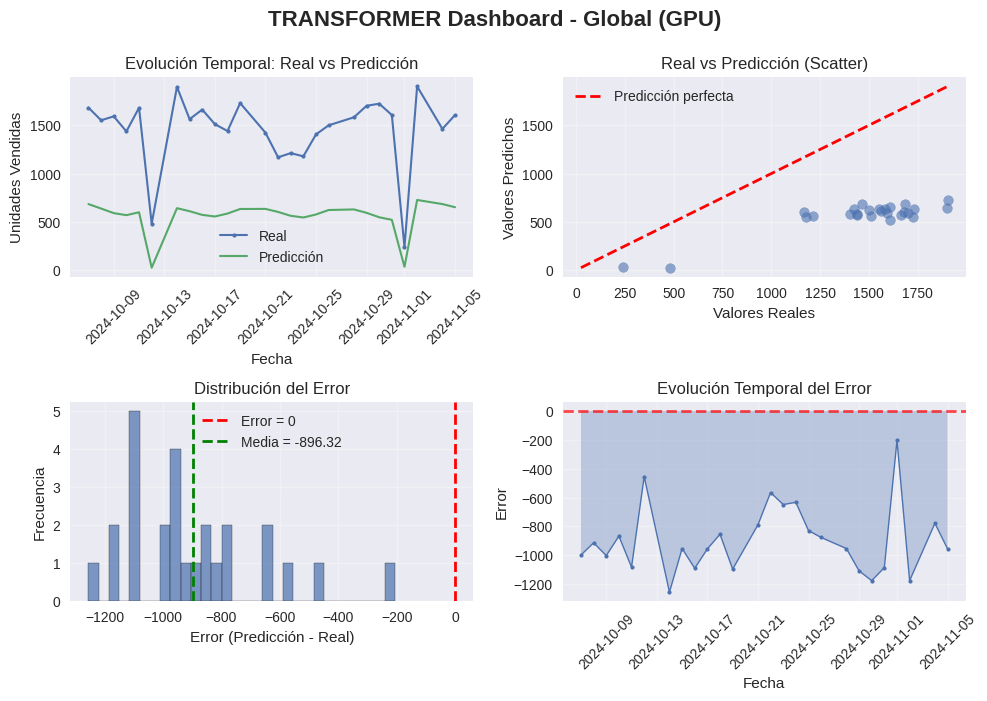

In [19]:
# Visualizaciones del modelo global
df_test_viz_sum = df_test_pred.groupby('idSecuencia')[['udsVenta', 'prediccion']].sum().reset_index()
df_test_viz_sum['error'] = df_test_viz_sum['prediccion'] - df_test_viz_sum['udsVenta']

dashboard_prediccion_dl(
        df=df_test_viz_sum,
        col_fecha='idSecuencia',
        col_real='udsVenta',
        col_pred='prediccion',
        titulo_principal=f'TRANSFORMER Dashboard - Global ({ACCELERATOR.upper()})',
        figsize=(10, 7)
        )

# TRANSFORMER por Cluster

Procesando Cluster_0:
  - df_train_nf_c: 210700 filas
  - df_test_nf_c: 9331 filas

⏳ Entrenando modelo TRANSFORMER en GPU...


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ MAE           │      0 │ train │     0 │
│ 1 │ padder_train  │ ConstantPad1d │      0 │ train │     0 │
│ 2 │ scaler        │ TemporalNorm  │      0 │ train │     0 │
│ 3 │ enc_embedding │ DataEmbedding │  3.1 K │ train │     0 │
│ 4 │ dec_embedding │ DataEmbedding │  3.1 K │ train │     0 │
│ 5 │ encoder       │ TransEncoder  │  892 K │ train │     0 │
│ 6 │ decoder       │ TransDecoder  │  1.7 M │ train │     0 │
└───┴───────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 2.6 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.6 M                                                                                                
Total estimated model params size (MB): 10                                                                         
Modules in train mode: 126                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=1000` reached.


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()


✅ Entrenamiento completado en 570.51 segundos (9.51 minutos)

⏳ Generando predicciones en test set con GPU...



✅ Predicciones generadas en 0.24 segundos

🔧 PREPARANDO PREDICCIONES PARA MÉTRICAS Y GRÁFICOS

📊 Métricas del Modelo para Cluster_0:

📊 RESUMEN DE MÉTRICAS
      Algoritmo NDetalle  Cluster Producto    MAE   RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
TRANSFORMER_GPU  Cluster        0     None 1.7243 2.7616 -0.0361     50.67     139.98 0.7939     89.3

🏆 Mejor modelo: TRANSFORMER_GPU (RMSE: 2.7616)


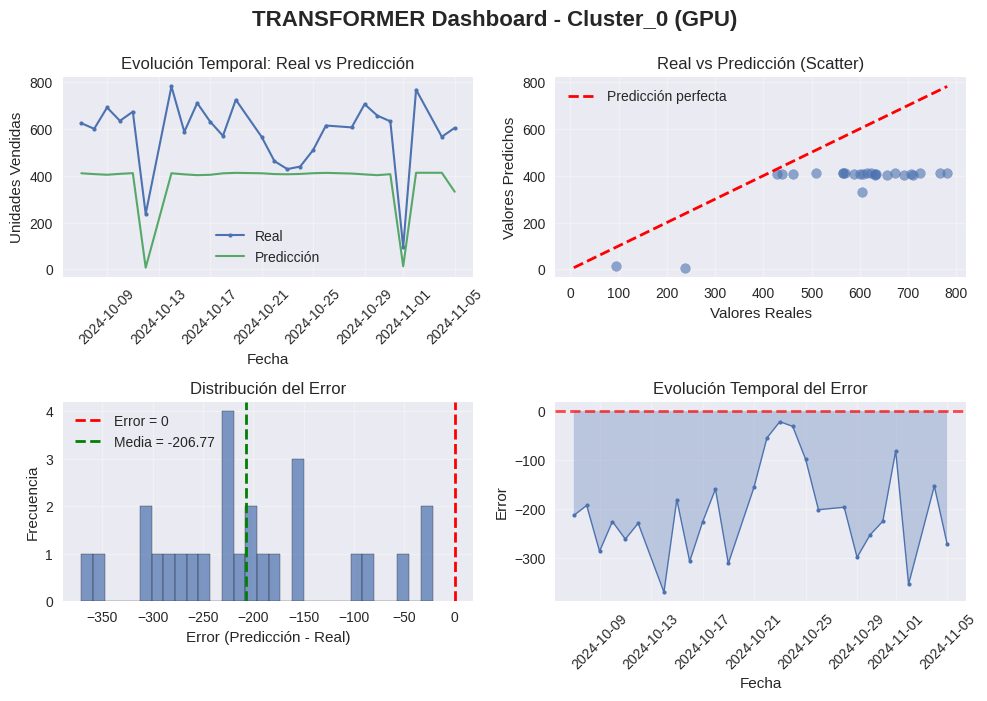

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Procesando Cluster_1:
  - df_train_nf_c: 74200 filas
  - df_test_nf_c: 3286 filas

⏳ Entrenando modelo TRANSFORMER en GPU...


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ MAE           │      0 │ train │     0 │
│ 1 │ padder_train  │ ConstantPad1d │      0 │ train │     0 │
│ 2 │ scaler        │ TemporalNorm  │      0 │ train │     0 │
│ 3 │ enc_embedding │ DataEmbedding │  3.1 K │ train │     0 │
│ 4 │ dec_embedding │ DataEmbedding │  3.1 K │ train │     0 │
│ 5 │ encoder       │ TransEncoder  │  892 K │ train │     0 │
│ 6 │ decoder       │ TransDecoder  │  1.7 M │ train │     0 │
└───┴───────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 2.6 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.6 M                                                                                                
Total estimated model params size (MB): 10                                                                         
Modules in train mode: 126                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=1000` reached.


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()


✅ Entrenamiento completado en 577.73 segundos (9.63 minutos)

⏳ Generando predicciones en test set con GPU...



✅ Predicciones generadas en 0.15 segundos

🔧 PREPARANDO PREDICCIONES PARA MÉTRICAS Y GRÁFICOS

📊 Métricas del Modelo para Cluster_1:

📊 RESUMEN DE MÉTRICAS
      Algoritmo NDetalle  Cluster Producto    MAE   RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
TRANSFORMER_GPU  Cluster        1     None 2.8484 4.0488 -0.0903     49.61     107.33 0.8092     74.7

🏆 Mejor modelo: TRANSFORMER_GPU (RMSE: 4.0488)


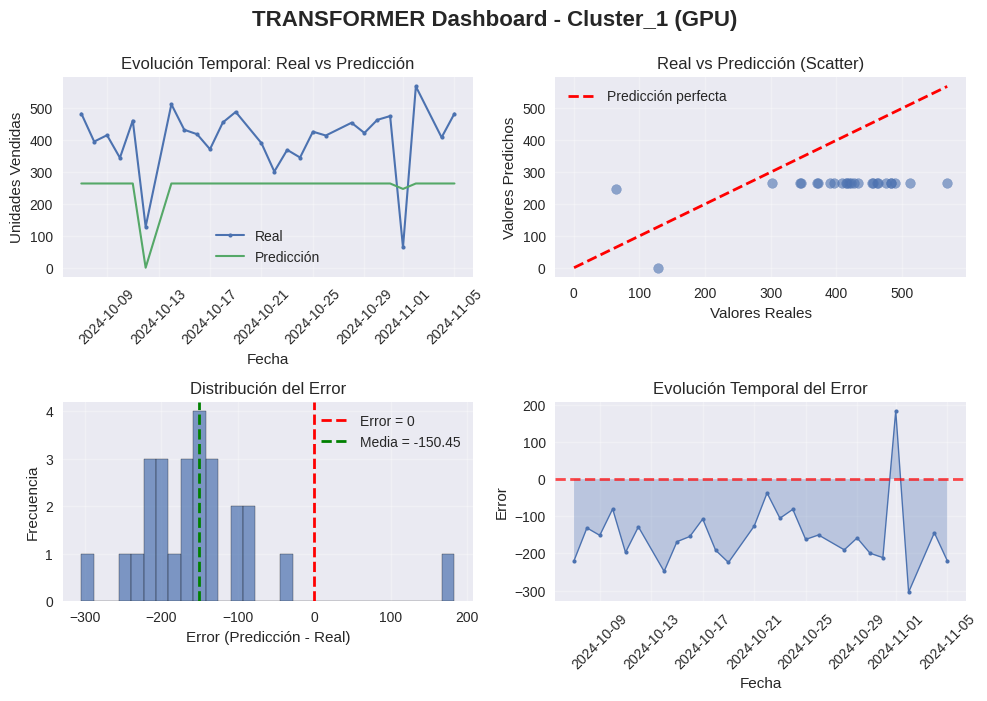

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Procesando Cluster_2:
  - df_train_nf_c: 11200 filas
  - df_test_nf_c: 496 filas

⏳ Entrenando modelo TRANSFORMER en GPU...


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ MAE           │      0 │ train │     0 │
│ 1 │ padder_train  │ ConstantPad1d │      0 │ train │     0 │
│ 2 │ scaler        │ TemporalNorm  │      0 │ train │     0 │
│ 3 │ enc_embedding │ DataEmbedding │  3.1 K │ train │     0 │
│ 4 │ dec_embedding │ DataEmbedding │  3.1 K │ train │     0 │
│ 5 │ encoder       │ TransEncoder  │  892 K │ train │     0 │
│ 6 │ decoder       │ TransDecoder  │  1.7 M │ train │     0 │
└───┴───────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 2.6 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.6 M                                                                                                
Total estimated model params size (MB): 10                                                                         
Modules in train mode: 126                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=1000` reached.


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()


✅ Entrenamiento completado en 572.77 segundos (9.55 minutos)

⏳ Generando predicciones en test set con GPU...



✅ Predicciones generadas en 0.18 segundos

🔧 PREPARANDO PREDICCIONES PARA MÉTRICAS Y GRÁFICOS

📊 Métricas del Modelo para Cluster_2:

📊 RESUMEN DE MÉTRICAS
      Algoritmo NDetalle  Cluster Producto    MAE   RMSE     R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
TRANSFORMER_GPU  Cluster        2     None 3.9064 5.5489 0.0485     60.77       85.8 0.7716    68.02

🏆 Mejor modelo: TRANSFORMER_GPU (RMSE: 5.5489)


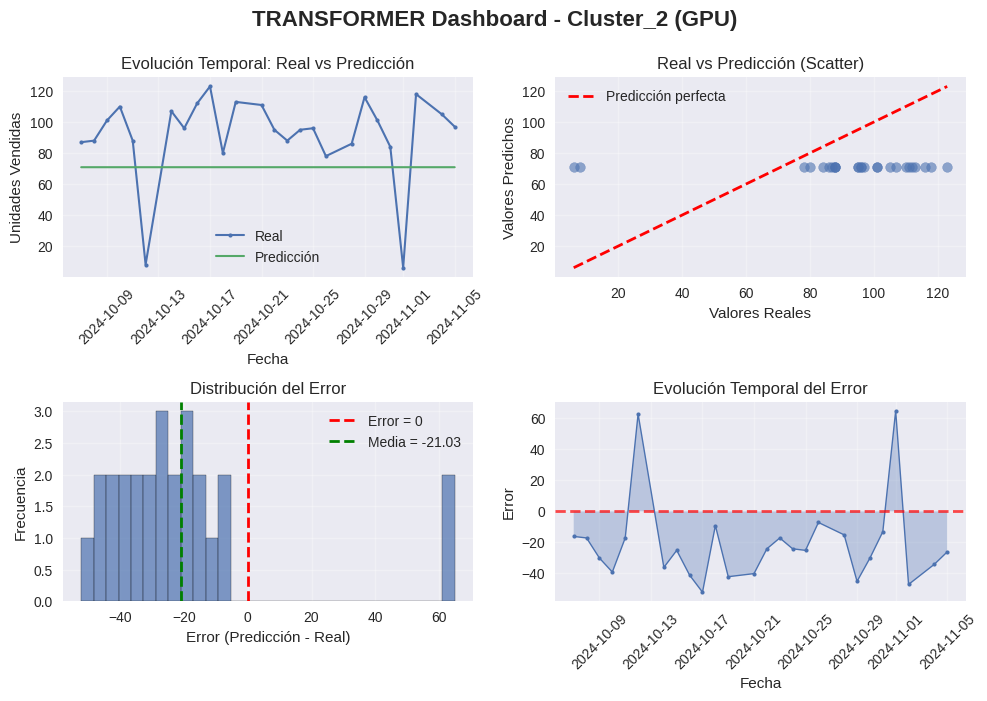

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Procesando Cluster_3:
  - df_train_nf_c: 329700 filas
  - df_test_nf_c: 14601 filas

⏳ Entrenando modelo TRANSFORMER en GPU...


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ MAE           │      0 │ train │     0 │
│ 1 │ padder_train  │ ConstantPad1d │      0 │ train │     0 │
│ 2 │ scaler        │ TemporalNorm  │      0 │ train │     0 │
│ 3 │ enc_embedding │ DataEmbedding │  3.1 K │ train │     0 │
│ 4 │ dec_embedding │ DataEmbedding │  3.1 K │ train │     0 │
│ 5 │ encoder       │ TransEncoder  │  892 K │ train │     0 │
│ 6 │ decoder       │ TransDecoder  │  1.7 M │ train │     0 │
└───┴───────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 2.6 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.6 M                                                                                                
Total estimated model params size (MB): 10                                                                         
Modules in train mode: 126                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=1000` reached.


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()


✅ Entrenamiento completado en 572.15 segundos (9.54 minutos)

⏳ Generando predicciones en test set con GPU...



✅ Predicciones generadas en 0.30 segundos

🔧 PREPARANDO PREDICCIONES PARA MÉTRICAS Y GRÁFICOS

📊 Métricas del Modelo para Cluster_3:

📊 RESUMEN DE MÉTRICAS
      Algoritmo NDetalle  Cluster Producto    MAE   RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
TRANSFORMER_GPU  Cluster        3     None 0.8087 1.8886 -0.1951     95.69     194.07 0.8475    99.58

🏆 Mejor modelo: TRANSFORMER_GPU (RMSE: 1.8886)


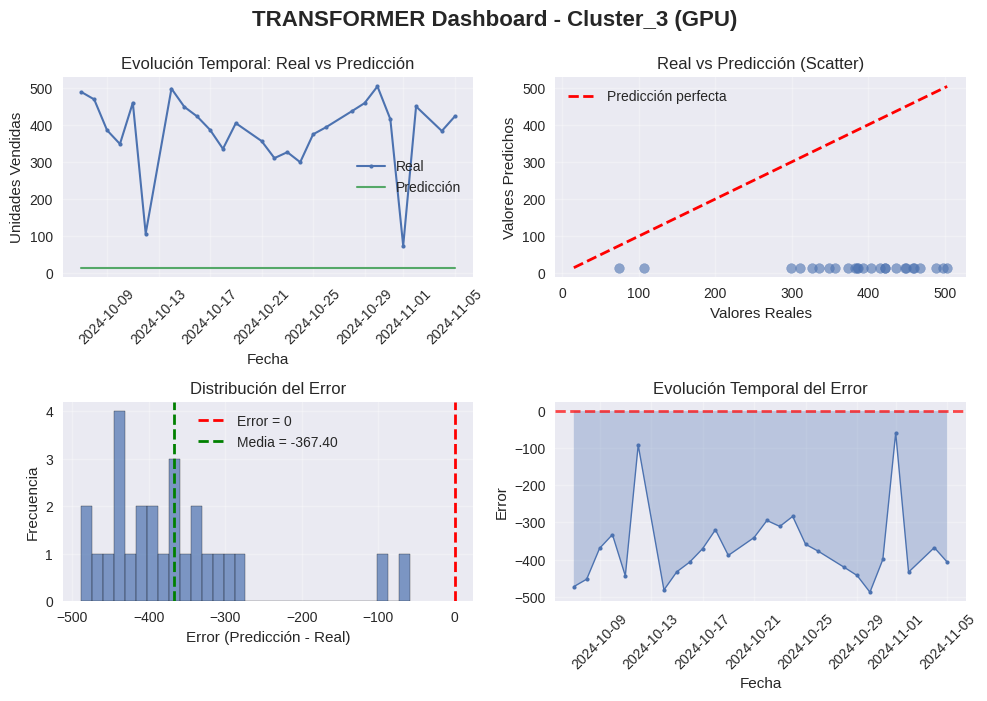

In [20]:
# Obtener las columnas que comienzan con 'Cluster_'
cluster_cols = [col for col in df_train_raw.columns if col.startswith('Cluster_')]

# Iterar sobre cada columna de cluster
for cluster_col in cluster_cols:
    # Filtrar df_test_nf usando la máscara de df_test_raw
    mask_test = df_test_raw[cluster_col] == 1
    df_test_nf_c = df_test_nf[mask_test]

    # Filtrar df_train_nf usando la máscara de df_train_raw
    mask_train = df_train_raw[cluster_col] == 1
    df_train_nf_c = df_train_nf[mask_train]

    # Aquí puedes trabajar con df_test_nf_c y df_train_nf_c
    print(f"Procesando {cluster_col}:")
    print(f"  - df_train_nf_c: {len(df_train_nf_c)} filas")
    print(f"  - df_test_nf_c: {len(df_test_nf_c)} filas")


    # Entrenar el modelo
    print(f"\n⏳ Entrenando modelo TRANSFORMER en {ACCELERATOR.upper()}...")
    start_time = time.perf_counter()
    nf.fit(df=df_train_nf_c, static_df=static_df)
    elapsed = time.perf_counter() - start_time
    print(f"\n✅ Entrenamiento completado en {elapsed:.2f} segundos ({elapsed/60:.2f} minutos)")

    # Realizar predicciones
    print(f"\n⏳ Generando predicciones en test set con {ACCELERATOR.upper()}...")
    start_time = time.perf_counter()
    y_hat = nf.predict(futr_df=df_test_nf_c)
    elapsed = time.perf_counter() - start_time
    print(f"\n✅ Predicciones generadas en {elapsed:.2f} segundos")

    df_test_pred = preparar_predicciones_test (y_hat, df_test_nf_c)

    # Calcular métricas por cluster y guardar
    df_valid = df_test_pred.dropna(subset=['prediccion', 'udsVenta'])
    cluster=int(cluster_col.split('_')[-1])
    # Calcular métricas
    metricas_transformer = calcular_metricas(
        y=df_valid['udsVenta'],
        y_pred=df_valid['prediccion'],
        algoritmo='TRANSFORMER_GPU' if ACCELERATOR == 'gpu' else 'TRANSFORMER_CPU',
        ndetalle= 'Cluster',
        cluster=cluster,
        producto=None
    )

    # Mostrar resumen
    print(f"\n📊 Métricas del Modelo para {cluster_col}:")
    resumen_metricas([metricas_transformer])

    todas_metricas.append(metricas_transformer)

    df_test_viz_sum = df_test_pred.groupby('idSecuencia')[['udsVenta', 'prediccion']].sum().reset_index()
    df_test_viz_sum['error'] = df_test_viz_sum['prediccion'] - df_test_viz_sum['udsVenta']

    dashboard_prediccion_dl(
            df=df_test_viz_sum,
            col_fecha='idSecuencia',
            col_real='udsVenta',
            col_pred='prediccion',
            titulo_principal=f'TRANSFORMER Dashboard - {cluster_col} ({ACCELERATOR.upper()})',
            figsize=(10, 7)
            )

    for producto in top_productos.get(cluster, []):
        idx_producto = (df_test_pred['producto'] == producto)
        y_test_prod = df_test_pred.loc[idx_producto, 'udsVenta']
        y_test_pred_prod = df_test_pred.loc[idx_producto, 'prediccion']
        metricas_producto = calcular_metricas(
            y_test_prod, y_test_pred_prod,
            algoritmo='TRANSFORMER_GPU' if ACCELERATOR == 'gpu' else 'TRANSFORMER_CPU',
            ndetalle='Cluster', cluster=int(cluster_col.split('_')[-1]), producto=producto)
        todas_metricas.append(metricas_producto)

# Resumen de métricas

In [21]:
# Ejecutar el resumen final usando la función de la librería
resumen_final_modelos(todas_metricas)


🏆 RESUMEN FINAL - COMPARACIÓN DE TODOS LOS MODELOS

📊 Resumen de todas las métricas (todas las columnas):
      Algoritmo NDetalle  Cluster  Producto    MAE      MSE    RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
TRANSFORMER_GPU  Cluster      3.0     314.0 0.0785   0.0062  0.0785  0.0000       NaN     200.00    NaN      NaN
TRANSFORMER_GPU  Cluster      3.0     257.0 0.5008   1.5756  1.2552 -0.1874     99.94     199.96 0.8541   100.16
TRANSFORMER_GPU  Cluster      3.0       NaN 0.8087   3.5667  1.8886 -0.1951     95.69     194.07 0.8475    99.58
TRANSFORMER_GPU  Cluster      0.0     413.0 1.4652   4.5319  2.1288  0.0637     24.11      90.27 0.7452    70.55
TRANSFORMER_GPU  Cluster      0.0       NaN 1.7243   7.6266  2.7616 -0.0361     50.67     139.98 0.7939    89.30
TRANSFORMER_GPU  Cluster      0.0     294.0 1.9209   8.2987  2.8807 -0.0404     32.90     127.06 0.6637   104.05
TRANSFORMER_GPU  Cluster      1.0       NaN 2.8484  16.3924  4.0488 -0.0903     49.61     107.33 0.809

# Guardar resultados

In [22]:
# ============================================================================
# GUARDAR RESULTADOS DE MÉTRICAS
# ============================================================================

print("\n" + "="*100)
print("💾 GUARDANDO RESULTADOS")
print("="*100)

# salvar resultados en fichero
df_resultados = pd.DataFrame(todas_metricas)
output_filename = f'datos/resultados_metricas_transformer_{"gpu" if ACCELERATOR == "gpu" else "cpu"}.csv'
df_resultados.to_csv(output_filename, index=False)

print(f"\n✅ Métricas guardadas en: {output_filename}")
print(f"   Configuración: {ACCELERATOR.upper()}")
print(f"   Filas guardadas: {len(df_resultados)}")

if ACCELERATOR == 'gpu':
    print("\n📊 Resumen de uso de GPU:")
    print(f"   Memoria GPU usada: {torch.cuda.memory_allocated(0) / 1e9:.2f} GB")
    print(f"   Memoria GPU máxima: {torch.cuda.max_memory_allocated(0) / 1e9:.2f} GB")


💾 GUARDANDO RESULTADOS

✅ Métricas guardadas en: datos/resultados_metricas_transformer_gpu.csv
   Configuración: GPU
   Filas guardadas: 25

📊 Resumen de uso de GPU:
   Memoria GPU usada: 0.00 GB
   Memoria GPU máxima: 5.72 GB
